In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, MaxPooling2D, Flatten, Conv2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50, EfficientNetB1
from tensorflow.keras.layers import GlobalAveragePooling2D


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "anshiagarwal",\r\n  "key": "KGAT_2759fd140ed93adc64471ec4436287bb"\r\n}\r\n'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saidaminsaidaxmadov/chocolate-sales                                 Chocolate Sales                                         468320  2026-01-04 14:23:35.490000          10651        173  1.0              
jayjoshi37/customer-subscription-churn-and-usage-patterns           Customer Subscription Churn and Usage Patterns           34246  2026-01-27 13:53:52.857000            667         23  1.0              
vishardmehta/indian-engineering-college-placement-dataset           Indian Engineering College Placement Dataset            137603  2026-01-24 15:23:40.150000           1660         44

In [6]:

!kaggle datasets download -d alifatahi/multi-class-neurological-disorder-mcnd-dataset


Dataset URL: https://www.kaggle.com/datasets/alifatahi/multi-class-neurological-disorder-mcnd-dataset
License(s): CC0-1.0
 99% 500M/503M [00:08<00:00, 116MB/s]
100% 503M/503M [00:08<00:00, 62.4MB/s]


In [7]:
if not os.path.exists("/content/mcnd_dataset"):
  !unzip /content/multi-class-neurological-disorder-mcnd-dataset.zip -d /content/mcnd_dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/mcnd_dataset/Normal/C-S (330).png  
  inflating: /content/mcnd_dataset/Normal/C-S (331).png  
  inflating: /content/mcnd_dataset/Normal/C-S (332).png  
  inflating: /content/mcnd_dataset/Normal/C-S (333).png  
  inflating: /content/mcnd_dataset/Normal/C-S (334).png  
  inflating: /content/mcnd_dataset/Normal/C-S (335).png  
  inflating: /content/mcnd_dataset/Normal/C-S (336).png  
  inflating: /content/mcnd_dataset/Normal/C-S (337).png  
  inflating: /content/mcnd_dataset/Normal/C-S (338).png  
  inflating: /content/mcnd_dataset/Normal/C-S (339).png  
  inflating: /content/mcnd_dataset/Normal/C-S (34).png  
  inflating: /content/mcnd_dataset/Normal/C-S (340).png  
  inflating: /content/mcnd_dataset/Normal/C-S (341).png  
  inflating: /content/mcnd_dataset/Normal/C-S (342).png  
  inflating: /content/mcnd_dataset/Normal/C-S (343).png  
  inflating: /content/mcnd_dataset/Normal/C-S (344).png  
  inflating: /content/

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
save_dir = "/content/drive/MyDrive/MRI_Project/model_training"

In [10]:
sample_path = "/content/mcnd_dataset/AD_MildDemented/26 (20).jpg"

In [11]:
img = cv2.imread(sample_path)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

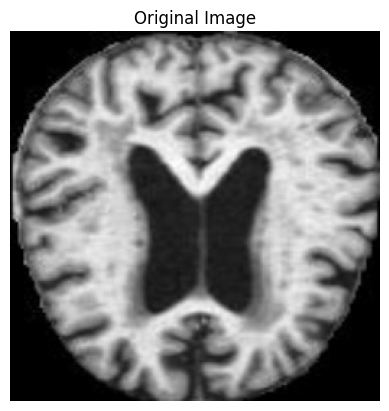

In [12]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

In [13]:
img_rgb.shape

(256, 256, 3)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

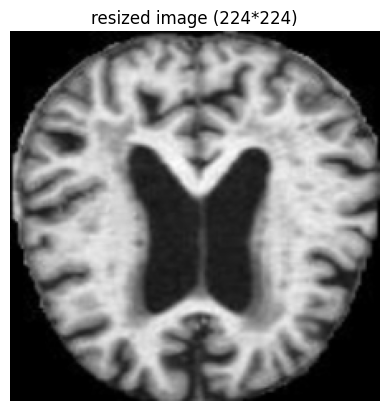

In [14]:
# Resizing and Reshaping

size = 224   #restnet expects 224
resized = cv2.resize(img_rgb, (size, size))
plt.imshow(resized)
plt.title("resized image (224*224)")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

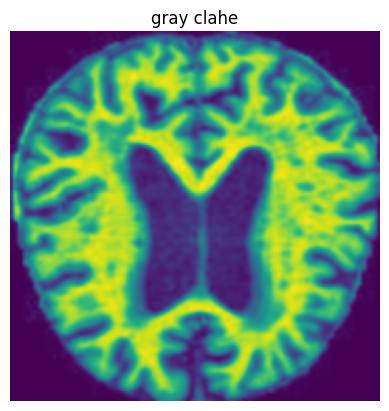

In [15]:
gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

# Mild smoothing
smooth = cv2.GaussianBlur(gray, (3,3), 0)

# Contrast Enhancement (CLAHE) Contrast Limited Adaptive Histogram Equalization
clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(smooth)


plt.imshow(gray_clahe)
plt.title("gray clahe")
plt.axis("off")

In [16]:
normalized = gray_clahe/255.0

final_img = np.stack([normalized]*3, axis=-1)


0.00784313725490196 0.9921568627450981


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

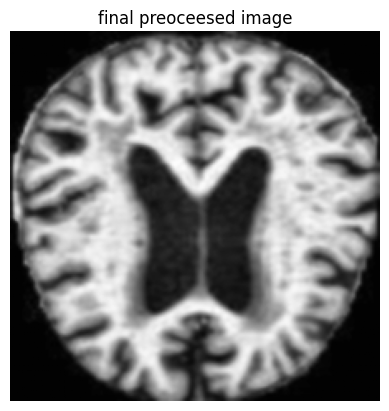

In [17]:
print(final_img.min(), final_img.max())
plt.imshow(final_img)
plt.title("final preoceesed image")
plt.axis("off")

In [18]:
# size = 224
# def preprocess_image(path):
#     img = cv2.imread(path)

#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     resized = cv2.resize(img_rgb, (size, size))
#     gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)

#     smooth = cv2.GaussianBlur(gray, (3, 3), 0)
#     clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
#     gray_clahe = clahe.apply(smooth)

#     normalized = gray_clahe/255.0
#     final_img = np.stack([normalized]*3, axis=-1)
#     return final_img.astype(np.float32)


In [2]:
dataset_path = "/content/mcnd_dataset"
class_names = sorted(os.listdir(dataset_path))

In [3]:
class_names

['AD_MildDemented',
 'AD_ModerateDemented',
 'AD_VeryMildDemented',
 'BT_glioma',
 'BT_meningioma',
 'BT_pituitary',
 'MS',
 'Normal']

In [4]:
data_dir = "/content/mcnd_dataset"

file_paths = []
labels = []

for label, folder in enumerate(class_names):

    folder_path = os.path.join(data_dir, folder)

    for file in os.listdir(folder_path):
        file_paths.append(os.path.join(folder_path, file))
        labels.append(label)

In [5]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [160, 160])
    img = img / 255.0
    return img, label

In [6]:

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")


AD_MildDemented: 896 images
AD_ModerateDemented: 64 images
AD_VeryMildDemented: 2240 images
BT_glioma: 1620 images
BT_meningioma: 1531 images
BT_pituitary: 1740 images
MS: 1405 images
Normal: 6904 images


In [7]:
from collections import defaultdict
import random

class_files = defaultdict(list)

for path, label in zip(file_paths, labels):
    class_files[label].append(path)

In [8]:
train_files = []
train_labels = []
test_files = []
test_labels = []

for label, files in class_files.items():
    random.shuffle(files)

    split_idx = int(0.8 * len(files))

    train_files.extend(files[:split_idx])
    train_labels.extend([label] * split_idx)

    test_files.extend(files[split_idx:])
    test_labels.extend([label] * (len(files) - split_idx))

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(32)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(32)
    .prefetch(AUTOTUNE)
)

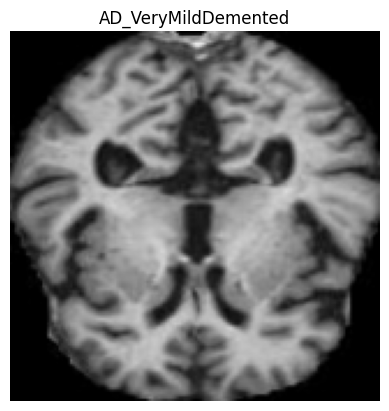

In [10]:
for img, label in train_ds.take(1):
    plt.imshow(img[0])
    plt.title(class_names[label[0].numpy()])
    plt.axis("off")
    plt.show()

In [11]:
# np.unique(train_labels, return_counts=True)

In [12]:
# class_weights = compute_class_weight(
#     class_weight = "balanced",
#     classes = np.unique(train_labels),
#     y = train_labels
# )
# class_weights

In [13]:
# class_weights = dict(enumerate(class_weights))
# print(class_weights)

In [14]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

In [15]:
# cnn_model = Sequential([
#     Conv2D(32, kernel_size = (3, 3), activation = "relu", input_shape = (160, 160, 3)),
#     MaxPooling2D(pool_size = (2, 2)),
#     Conv2D(64, kernel_size = (3, 3), activation ="relu"),
#     MaxPooling2D(pool_size = (2, 2)),
#     Conv2D(128, kernel_size = (3, 3), activation = "relu"),
#     Flatten(),
#     Dense(256, activation='relu'),
#     Dropout(0.5),
#     Dense(128, activation='relu'),
#     Dropout(0.3),
#     Dense(8, activation='softmax')
# ])

In [16]:
# cnn_model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [17]:
# history = cnn_model.fit(train_ds, epochs = 15, validation_data = test_ds, verbose = 1, class_weight=class_weights, callbacks=[early_stop])

In [18]:
# cnn_model.save('/content/drive/MyDrive/cnn_mri_model.h5')

In [19]:
# base_model = ResNet50(
#     weights = "imagenet",
#     include_top = False,
#     input_shape = (160, 160, 3)
# )

In [20]:
# base_model.trainable = False

In [21]:
# resnet_model = Sequential([
#     base_model,
#     GlobalAveragePooling2D(),
#     Dense(128, activation='relu'),
#     Dropout(0.5),
#     Dense(8, activation='softmax')
# ])

In [22]:
# resnet_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

In [23]:
# history_resnet = resnet_model.fit(
#     train_ds,
#     validation_data=test_ds,
#     epochs=1,
#     callbacks=[early_stop],
#     verbose = 1
# )

In [24]:
# resnet_model.save('/content/drive/MyDrive/resnet_mri_model.h5')

In [25]:
from tensorflow.keras.applications import EfficientNetB1
base_model_EfficientNetB1 = EfficientNetB1(
    weights = "imagenet",
    include_top = False,
    input_shape = (160, 160, 3)
)

In [26]:
base_model_EfficientNetB1.trainable = False

In [27]:
EfficientNetB1_model = Sequential([
    base_model_EfficientNetB1,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(8, activation='softmax')
])

In [28]:
EfficientNetB1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history_EfficientNetB1 = EfficientNetB1_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[early_stop],
    verbose = 1
)

Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 879s 2s/step - accuracy: 0.5320 - loss: 1.2322 - val_accuracy: 0.4208 - val_loss: 5.7913
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 808s 2s/step - accuracy: 0.1366 - loss: 3.2853 - val_accuracy: 0.4208 - val_loss: 1.9325
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 775s 2s/step - accuracy: 0.2466 - loss: 1.8097 - val_accuracy: 0.4208 - val_loss: 5.6190
Epoch 4/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 788s 2s/step - accuracy: 0.1104 - loss: 2.7296 - val_accuracy: 0.4208 - val_loss: 1.8172
Epoch 5/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 780s 2s/step - accuracy: 0.1237 - loss: 2.0637 - val_accuracy: 0.4208 - val_loss: 1.7749
Epoch 6/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 779s 2s/step - accuracy: 0.1104 - loss: 2.0669 - val_accuracy: 0.4208 - val_loss: 4.8780
Epoch 7/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.1105 - loss: 2.5994 - val_accuracy: 0.4208 - val_loss: 1.7507
Epoch 8/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 805s 2s/step - accuracy: 0.1105 - loss: 2.1073 - val_accu

In [32]:
EfficientNetB1_model.save(
    f"{save_dir}/EfficientNetB1_mri_model.keras"
)

In [33]:
loss, accuracy = EfficientNetB1_model.evaluate(test_ds)
print("Test Accuracy:", accuracy)

103/103 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.1109 - loss: 2.2163
Test Accuracy: 0.4207800030708313


In [35]:
# EfficientNetB1_model = tf.keras.models.load_model('/content/drive/MyDrive/EfficientNetB1_mri_model.keras')

In [36]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = EfficientNetB1_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
